In [1]:
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
import vector
from rich import print
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist

In [2]:
sys.path.insert(0, "../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
matplotlib.rcParams["figure.facecolor"] = "white"
hep.style.use(hep.style.CMS)

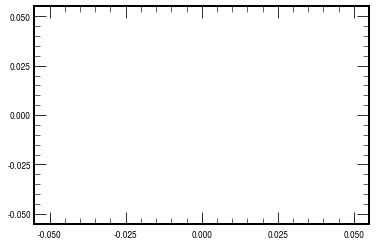

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

## Process files
NOTE: These files are just the merged NANOAOD files for `GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8`

In [7]:
file_2016APV = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2016APV.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2016 = nanoevents.NanoEventsFactory.from_root(
    # merged result of dasgoclient -query="file dataset=/GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v2/NANOAODSIM"
    "~/nobackup/nano_2016.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2017 = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2017.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2018 = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2018.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events_2016APV = file_2016APV.events()
events_2016 = file_2016.events()
events_2017 = file_2017.events()
events_2018 = file_2018.events()

All gen models in `GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8`

In [8]:
print(len(events_2016APV))
print(len(events_2016))
print(len(events_2017))
print(len(events_2018))

225000

225000

448000

450000

Select gen model of interest

In [58]:
events_2016APV = events_2016APV[
    events_2016APV.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]
events_2016 = events_2016[
    events_2016.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]
events_2017 = events_2017[
    events_2017.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]
events_2018 = events_2018[
    events_2018.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]

Only SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic

In [59]:
print(len(events_2016APV))
print(len(events_2016))
print(len(events_2017))
print(len(events_2018))

26000

27090

53000

63000

In [75]:
events_2016APV = events_2016APV[
    ak.firsts(
        events_2016APV.GenPart[
            (events_2016APV.GenPart.pdgId == 25) & (events_2016APV.GenPart.status == 62)
        ]
    ).mass
    == 125
]
events_2016 = events_2016[
    ak.firsts(
        events_2016.GenPart[
            (events_2016.GenPart.pdgId == 25) & (events_2016.GenPart.status == 62)
        ]
    ).mass
    == 125
]
events_2017 = events_2017[
    ak.firsts(
        events_2017.GenPart[
            (events_2017.GenPart.pdgId == 25) & (events_2017.GenPart.status == 62)
        ]
    ).mass
    == 125
]
events_2018 = events_2018[
    ak.firsts(
        events_2018.GenPart[
            (events_2018.GenPart.pdgId == 25) & (events_2018.GenPart.status == 62)
        ]
    ).mass
    == 125
]

Passing the HLT_TripleMu_5_3_3 trigger **large difference in acceptance**

In [49]:
print(ak.sum(events_2016APV.HLT.TripleMu_5_3_3))
print(ak.sum(events_2016.HLT.TripleMu_5_3_3))
print(ak.sum(events_2017.HLT.TripleMu_5_3_3))
print(ak.sum(events_2018.HLT.TripleMu_5_3_3))

21495

9473

AttributeError: no field named 'TripleMu_5_3_3'

(https://github.com/scikit-hep/awkward-1.0/blob/1.10.5/src/awkward/highlevel.py#L1124)

Apply the trigger

In [12]:
events_2016APV = events_2016APV[events_2016APV.HLT.TripleMu_5_3_3]
events_2016 = events_2016[events_2016.HLT.TripleMu_5_3_3]

Number of muons **large difference**

In [13]:
print(ak.num(events_2016APV.Muon))
print(ak.num(events_2016.Muon))

[11, 17, 9, 26, 15, 10, 14, 24, 13, 17, ... 20, 10, 17, 23, 30, 8, 15, 14, 22, 20]

[4, 4, 3, 4, 6, 4, 5, 4, 5, 3, 5, 5, 4, 7, ... 5, 7, 5, 4, 4, 4, 6, 4, 4, 4, 4, 5, 3]

Checking the muon pt's (looks okay)

In [14]:
print(events_2016APV.Muon.pt)
print(events_2016.Muon.pt)

[[89.7, 58.6, 44.8, 41.3, 24.3, 23.6, 15.9, ... 10.7, 9.8, 8, 7.66, 6.83, 5.6, 5.07]]

[[50.7, 40.1, 36.1, 5.05], [19.4, 18.5, ... 13.7, 12.6, 11.3], [26.5, 13.1, 8.15]]

Checking number of gen level particles **large difference**

In [50]:
print(ak.sum(events_2016APV.GenPart.pdgId == 999999, axis=-1))
print(ak.sum(events_2016.GenPart.pdgId == 999999, axis=-1))
print(ak.sum(events_2017.GenPart.pdgId == 999999, axis=-1))
print(ak.sum(events_2018.GenPart.pdgId == 999999, axis=-1))

[8, 11, 12, 15, 12, 10, 11, 13, 10, 13, ... 16, 14, 12, 17, 14, 8, 11, 14, 22, 18]

[3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, ... 2, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2]

[2, 2, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3]

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [51]:
print(ak.sum(events_2016APV.GenPart.pdgId == 999998, axis=-1))
print(ak.sum(events_2016.GenPart.pdgId == 999998, axis=-1))
print(ak.sum(events_2017.GenPart.pdgId == 999998, axis=-1))
print(ak.sum(events_2018.GenPart.pdgId == 999998, axis=-1))

[8, 13, 8, 18, 13, 11, 7, 19, 12, 14, 12, ... 19, 11, 12, 20, 16, 6, 12, 13, 21, 20]

[2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 4, 3, ... 1, 2, 3, 3, 2, 4, 2, 1, 2, 2, 3, 0, 1]

[2, 2, 2, 3, 2, 2, 3, 1, 2, 2, 3, 1, 2, 2, ... 3, 1, 1, 2, 2, 4, 2, 1, 4, 1, 4, 1, 3]

[3, 1, 2, 1, 3, 2, 4, 0, 3, 3, 3, 4, 1, 3, ... 2, 1, 3, 2, 1, 1, 1, 0, 2, 2, 2, 1, 4]

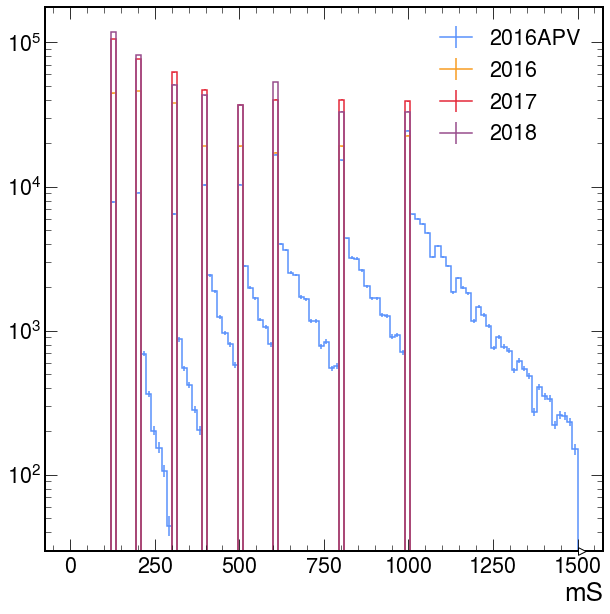

In [9]:
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2016APV.GenPart[
            (events_2016APV.GenPart.pdgId == 25) & (events_2016APV.GenPart.status == 62)
        ].mass
    )
).plot(label="2016APV")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2016.GenPart[
            (events_2016.GenPart.pdgId == 25) & (events_2016.GenPart.status == 62)
        ].mass
    )
).plot(label="2016")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2017.GenPart[
            (events_2017.GenPart.pdgId == 25) & (events_2017.GenPart.status == 62)
        ].mass
    )
).plot(label="2017")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2018.GenPart[
            (events_2018.GenPart.pdgId == 25) & (events_2018.GenPart.status == 62)
        ].mass
    )
).plot(label="2018")
plt.legend()
plt.yscale("log")
plt.xlabel("mS")
plt.show()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fc1a5baf150>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

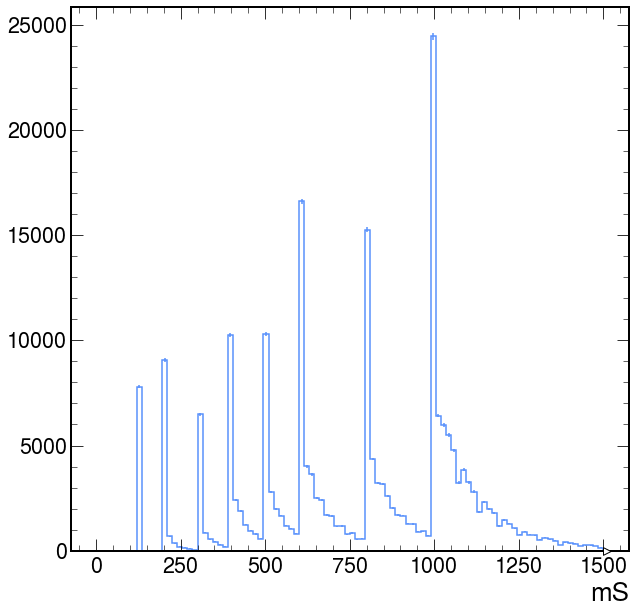

In [35]:
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2016APV.GenPart[
            (events_2016APV.GenPart.pdgId == 25) & (events_2016APV.GenPart.status == 62)
        ].mass
    )
).plot()

In [33]:
events_2016APV.GenPart[events_2016APV.GenPart.pdgId == 25].status

<Array [[22, 44, 44, 44, ... 44, 44, 44, 62]] type='225000 * var * int32[paramet...'>

In [77]:
file_2022 = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2022.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2022EE = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2022EE.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2023 = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2017.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2023BPix = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2023BPix.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events_2022 = file_2022.events()
events_2022EE = file_2022EE.events()
events_2023 = file_2023.events()
events_2023BPix = file_2023BPix.events()

In [79]:
print(len(events_2022))
print(len(events_2022EE))
print(len(events_2023))
print(len(events_2023BPix))

132000

252000

448000

141000

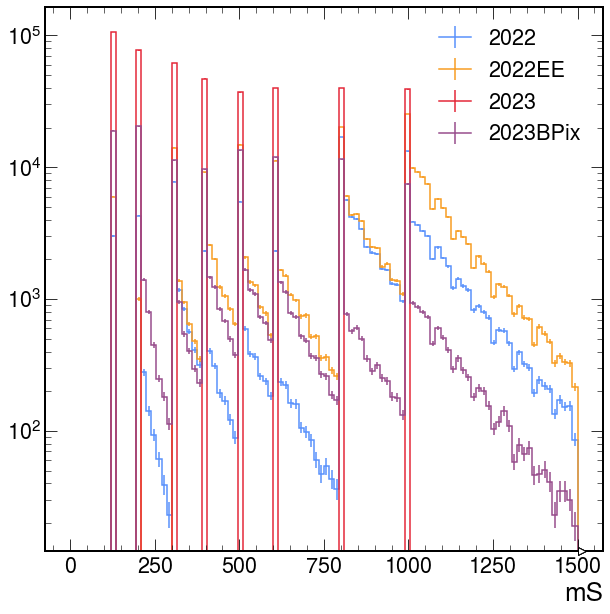

In [80]:
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2022.GenPart[
            (events_2022.GenPart.pdgId == 25) & (events_2022.GenPart.status == 62)
        ].mass
    )
).plot(label="2022")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2022EE.GenPart[
            (events_2022EE.GenPart.pdgId == 25) & (events_2022EE.GenPart.status == 62)
        ].mass
    )
).plot(label="2022EE")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2023.GenPart[
            (events_2023.GenPart.pdgId == 25) & (events_2023.GenPart.status == 62)
        ].mass
    )
).plot(label="2023")
hist.Hist.new.Regular(100, 0, 1500, name="mS").Double().fill(
    ak.flatten(
        events_2023BPix.GenPart[
            (events_2023BPix.GenPart.pdgId == 25)
            & (events_2023BPix.GenPart.status == 62)
        ].mass
    )
).plot(label="2023BPix")
plt.legend()
plt.yscale("log")
plt.xlabel("mS")
plt.show()